# OVFToolkit spectrum-processing workflow

OVFToolkit provides a high-performance C++ parser and tools for working with MuMax3 and OOMMF outputs. In this example, we run a representative MuMax3 simulation and process its results. MuMax3 must be available on `PATH`.

## Create a temporary workspace

The simulation and processing steps use a temporary directory. Set `work_dir` to a permanent location instead if you want to retain the generated artifacts.

In [19]:
import shutil
import tempfile
from pathlib import Path

# Remove the previous temporary workspace when rerunning the notebook.
if "work_dir" in globals():
    shutil.rmtree(work_dir, ignore_errors=True)

work_dir = Path(tempfile.mkdtemp(prefix="ovftoolkit-"))
print(work_dir)

C:\Users\Artej\AppData\Local\Temp\ovftoolkit-tpg4jay4


## Configure the MuMax3 simulation

The included `vortex-dynamics.mx3.in` template defines a cylindrical geometry 640 nm in diameter and 20 nm thick, discretized into cells measuring 2.5 nm $\times$ 2.5 nm $\times$ 10 nm. It uses representative permalloy parameters: saturation magnetization $M_\text{sat} = 830$ kA/m and exchange stiffness $A_\text{ex} = 13$ pJ/m. The notebook fills its experiment block for both broadband and continuous-wave simulations.

The magnetization is initialized in a vortex state and relaxed using MuMax3's `minimize()` API.

Dynamics are excited by a broadband $\operatorname{sinc}$ pulse. An unshifted $\operatorname{sinc}(2\pi f_\text{max}t)$ has a flat spectrum up to $f_\text{max}$. Because the simulation begins at $t=0$, we instead use $\operatorname{sinc}(2\pi f_\text{max}t-\phi_0)$ with $\phi_0 \approx 32.313$, chosen such that

$$
\frac{\int_{-\phi_0}^{\infty} \operatorname{sinc}^2(x)\,dx}{\int_{-\infty}^{\infty} \operatorname{sinc}^2(x)\,dx}=0.995.
$$

Thus, 99.5% of the pulse energy lies within the simulated interval $[0,\infty)$. The shift is approximately five periods and is independent of the cutoff frequency.

MuMax3 writes telemetry to `{mumax_out_dir}/table.txt` and field snapshots to `{mumax_out_dir}/*.ovf`. The 10 MHz frequency resolution deliberately produces a large dataset to demonstrate OVFToolkit's streaming processing. Generating the simulation may take several hours, while post-processing should take only minutes.

### Resolve files relative to the notebook

This keeps the example portable regardless of the directory from which Jupyter was launched. The MuMax3 source is displayed before execution so its simulation parameters remain visible in the notebook.

In [20]:
%pip install -q ipynbname matplotlib pandas scipy
import ipynbname

notebook_path = ipynbname.path()
notebook_directory = notebook_path.parent
mumax_template = notebook_directory / "vortex-dynamics.mx3.in"
mumax_source = work_dir / "vortex-dynamics.mx3"

def render_mumax(experiment, destination):
    source = mumax_template.read_text(encoding="utf-8")
    if source.count("@EXPERIMENT@") != 1:
        raise ValueError("Expected exactly one @EXPERIMENT@ placeholder")
    destination.write_text(
        source.replace("@EXPERIMENT@", experiment.strip()),
        encoding="utf-8",
    )
    return destination

broadband_experiment = r"""
SaveAs(m, "eq-mag.ovf")

// Broadband excitation and frequency sampling
df     := 10e6  // Hz
f_samp := 20e9  // Hz
f_exc  := 8e9   // Hz
B_amp  := 5e-3  // T

B_ext = Vector(0, B_amp * sinc(2*pi*f_exc*t - 32.313), 0)

TableAdd(B_ext)
TableAdd(E_total)
TableAdd(ext_corepos)
TableAutoSave(1/f_samp)
AutoSave(m, 1/f_samp)
run(1/df - 1/(2*f_samp))
"""
render_mumax(broadband_experiment, mumax_source)

mumax_out_dir = work_dir / "mumax-output"
mumax_out_dir.mkdir(parents=True, exist_ok=True)

from IPython.display import Code, display

display(Code(mumax_source.read_text(encoding="utf-8"), language="go"))

Note: you may need to restart the kernel to use updated packages.


Nlat := 256
Nz   := 2
dLat := 2.5e-9
dZ   := 10e-9

SetMesh(
    // x       y          z
    Nlat,     Nlat,     Nz,      // grid cells
    dLat,     dLat,     dZ,      // cell size (m)
    0,        0,        0)       // periodic repetitions


Msat  = 830e3  // A/m
Aex   = 13e-12 // J/m
alpha = 0.01

diam       := Nlat * dLat
EdgeSmooth  = 8
SetGeom(Cylinder(diam, Inf))
SaveAs(geom, "cyl-geometry.ovf")

m = Vortex(1, 1)
minimize()

SaveAs(m, "eq-mag.ovf")

// Broadband excitation and frequency sampling
df     := 10e6  // Hz
f_samp := 20e9  // Hz
f_exc  := 8e9   // Hz
B_amp  := 5e-3  // T

B_ext = Vector(0, B_amp * sinc(2*pi*f_exc*t - 32.313), 0)

TableAdd(B_ext)
TableAdd(E_total)
TableAdd(ext_corepos)
TableAutoSave(1/f_samp)
AutoSave(m, 1/f_samp)
run(1/df - 1/(2*f_samp))

## Run the simulation

Run MuMax3 and capture its console output in `mumax3_output`. When only one MuMax3 instance is active, live progress is normally available at [localhost:35367](http://localhost:35367).

In [21]:
%%capture mumax3_output
!mumax3 -o "{mumax_out_dir}" "{mumax_source}"

### Measure the generated dataset

The reusable helper below reports the total size of a directory in binary units.

In [22]:
def human_size(size):
    for unit in ("B", "KiB", "MiB", "GiB", "TiB"):
        if size < 1024:
            return f"{size:.2f} {unit}"
        size /= 1024
    return f"{size:.2f} PiB"

total_size = sum(
    path.stat().st_size
    for path in mumax_out_dir.rglob("*")
    if path.is_file()
)

print(f"MuMax3 total output size: {human_size(total_size)}")

MuMax3 total output size: 2.93 GiB


## Inspect the time-domain energy

Plot the system's excess energy relative to its first recorded, relaxed state, expressed in electronvolts. Because the ground-state difference is zero, only positive excess-energy values are shown on the logarithmic axis.

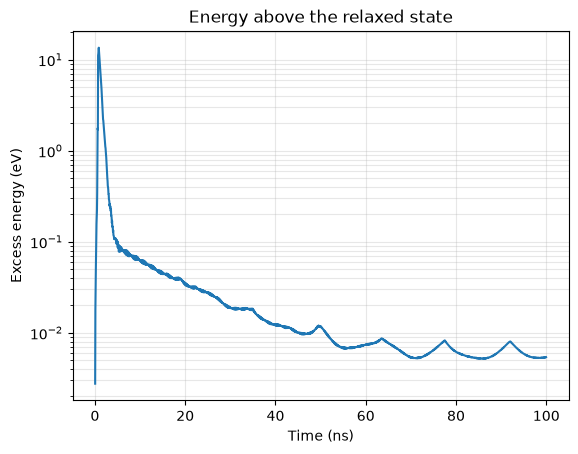

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.constants import electron_volt

table = pd.read_csv(mumax_out_dir / "table.txt", sep="\t")
table.columns = (
    table.columns.str.strip().str.removeprefix("# ").str.split().str[0]
)

excess_energy_ev = (table["E_total"] - table["E_total"].iloc[0]) / electron_volt
positive = excess_energy_ev > 0

fig, ax = plt.subplots()
ax.plot(table.loc[positive, "t"] * 1e9, excess_energy_ev[positive])
ax.set_yscale("log")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Excess energy (eV)")
ax.set_title("Energy above the relaxed state")
ax.grid(True, which="both", alpha=0.3)
plt.show()

## Transform snapshots into a frequency spectrum

`ovf-batchfft` converts the snapshot sequence into a single, multi-segment OVF file containing its temporal Fourier transform. It scales to datasets larger than system memory by buffering intermediate results in a temporary swap file.

In [24]:
# Adjust this path to the ovf-batchfft executable from your build.
batchfft = (
    notebook_directory
    / ".."
    / ".."
    / "build-win-static-v143"
    / "stage"
    / "bin"
    / "ovf-batchfft.exe"
).resolve()
spec_file = work_dir / "dejittered_spectrum.ovf"

!"{batchfft}" "{mumax_out_dir}/m*.ovf" -o "{spec_file}"

OVFToolkit time-domain FFT batch processing utility 0.2.1
Copyright (c) 2020-2026 Artem Bondarenko
Available FFT engines: gpu (cuFFT), fftw

Done pre-fetching .ovf metadata for 2000 files in 2.16829 seconds.
Found 786432000 values to be handled (2.93GB of data in single precision).
Input array has even time step of 5.00001e-11 seconds. Average time step is 5.00001e-11 seconds, and time step dispersion is 1.23764e-13 seconds. 
NVIDIA GeForce RTX 4070 Laptop GPU
Using GPU #0 "NVIDIA GeForce RTX 4070 Laptop GPU" 36SM@2175MHz, 8.00GBs of global memory on device (6.89GB free).
Chosen to do transforms in 219648 point batches (1.64GB each, 6.55GB together with work area in the gpu).
Exported a 2.93GB spectrum into "C:\Users\Artej\AppData\Local\Temp\ovftoolkit-tpg4jay4\dejittered_spectrum.ovf"


## Inspect the geometry mask

Load the scalar geometry fill and display the single $z$ layer as a grayscale image. A fill fraction of 0 is black and 1 is white.

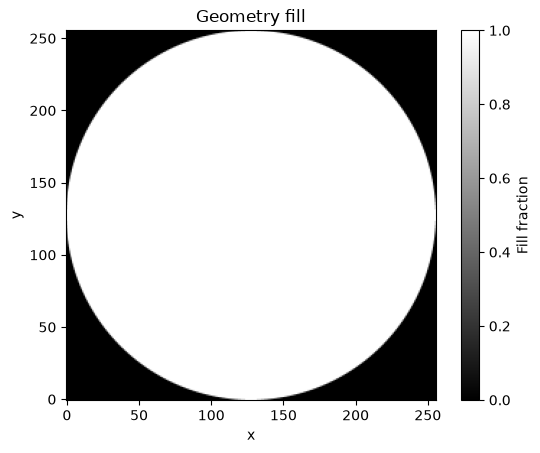

In [25]:
import ovftoolkit as ovf
import numpy as np

with ovf.reader(mumax_out_dir / "cyl-geometry.ovf") as geom_file:
    geom_fill = geom_file[0].data

fill_layer = geom_fill[0, ..., 0]
visible_fill = np.ma.masked_where(fill_layer <= 0, fill_layer)
geometry_cmap = plt.colormaps["gray"].copy()
geometry_cmap.set_bad(alpha=0)

fig, ax = plt.subplots()
image = ax.imshow(
    visible_fill,
    cmap=geometry_cmap,
    vmin=0,
    vmax=1,
    origin="lower",
)

ax.set_title("Geometry fill")
ax.set_xlabel("x")
ax.set_ylabel("y")

fig.colorbar(image, ax=ax, label="Fill fraction")
plt.show()

## Reduce the spectrum to macroparameters

Compute the geometry-weighted complex mean of each magnetization component and the RMS spectral amplitude at every frequency. The result provides named fields such as `f`, `mx`, `my`, `mz`, and `rms`.

In [26]:
macroparams = ovf.eval_macroparams(spec_file, mask=geom_fill)
macroparams.dtype.names

('f', 'mx', 'my', 'mz', 'rms')

## Plot the reduced spectrum

Compare the magnitude of the spatially averaged $x$ component with the total RMS amplitude on a shared logarithmic scale.

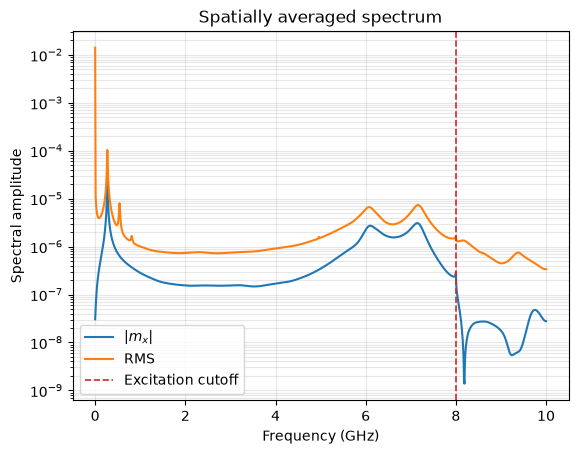

In [27]:
fig, ax = plt.subplots()
frequency_ghz = macroparams.f / 1e9

ax.plot(frequency_ghz, np.abs(macroparams.mx), label=r"$|m_x|$")
ax.plot(frequency_ghz, macroparams.rms, label="RMS")
ax.set_yscale("log")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Spectral amplitude")
ax.set_title("Spatially averaged spectrum")
ax.grid(True, which="both", alpha=0.3)

f_exc = 8e9  # Hz
f_exc_ghz = f_exc / 1e9

ax.axvline(
    f_exc_ghz,
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label="Excitation cutoff",
)

ax.set_xticks([f_exc_ghz], minor=True)
ax.set_xticklabels([r"$f_{\mathrm{exc}}$"], minor=True)
ax.tick_params(axis="x", which="minor", colors="tab:red", length=6)

ax.legend()
plt.show()

## Locate and refine the three strongest resonances

Detect the three most prominent peaks in $|m_x|$ below the excitation cutoff, then refine each center with a local Lorentzian fit. Frequencies are fitted in GHz to keep the numerical optimization well scaled.

In [28]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, peak_widths

def lorentzian(frequency, offset, height, center, hwhm):
    return offset + height * hwhm**2 / ((frequency - center)**2 + hwhm**2)

mx_magnitude = np.abs(macroparams.mx)
fit_band = np.flatnonzero((macroparams.f > 0) & (macroparams.f < f_exc))
candidate_local, properties = find_peaks(
    mx_magnitude[fit_band], distance=5, prominence=0
)
if candidate_local.size < 3:
    raise RuntimeError("Fewer than three resonance peaks were detected")

strongest = np.argsort(properties["prominences"])[-3:]
peak_indices = np.sort(fit_band[candidate_local[strongest]])
frequency_step_ghz = np.median(np.diff(frequency_ghz))
fit_rows = []

for mode, peak_index in enumerate(peak_indices, start=1):
    width_samples = peak_widths(mx_magnitude, [peak_index], rel_height=0.5)[0][0]
    half_window = max(4, int(np.ceil(2 * width_samples)))
    start = max(0, peak_index - half_window)
    stop = min(len(macroparams), peak_index + half_window + 1)
    local_f = frequency_ghz[start:stop]
    local_mx = mx_magnitude[start:stop]
    offset0 = local_mx.min()
    height0 = max(local_mx.max() - offset0, np.finfo(float).eps)
    hwhm0 = max(frequency_step_ghz, width_samples * frequency_step_ghz / 2)

    parameters, covariance = curve_fit(
        lorentzian,
        local_f,
        local_mx,
        p0=(offset0, height0, frequency_ghz[peak_index], hwhm0),
        bounds=(
            (0, 0, local_f[0], frequency_step_ghz / 20),
            (np.inf, np.inf, local_f[-1], local_f[-1] - local_f[0]),
        ),
        maxfev=20_000,
    )
    center_ghz = parameters[2]
    fit_rows.append(
        {
            "mode": mode,
            "frequency_hz": center_ghz * 1e9,
            "frequency_ghz": center_ghz,
            "fit_error_mhz": np.sqrt(covariance[2, 2]) * 1e3,
            "fwhm_mhz": 2 * parameters[3] * 1e3,
        }
    )

peak_table = pd.DataFrame(fit_rows).set_index("mode")
peak_table

,frequency_hz,frequency_ghz,fit_error_mhz,fwhm_mhz
mode,,,,
1,2.699993e+08,0.269999,1.210360,19.999960
2,6.180066e+09,6.180066,6.699686,660.036650
3,7.057603e+09,7.057603,19.838633,293.650674


## Excite each fitted mode continuously

Render one sine-driven MuMax3 input per fitted resonance. Each simulation settles under continuous-wave excitation for 50 ns without saving magnetization snapshots, then records exactly the final five driven cycles at eight samples per cycle (40 snapshots).

In [31]:
import subprocess

cw_experiment = r"""
// Continuous-wave excitation
f_drive         := @FREQUENCY_HZ@
B_amp           := 1e-4
t_eq            := 10e-9
cycles          := 5
samplesPerCycle := 8
sampleInterval  := 1 / (samplesPerCycle * f_drive)
B_ext = Vector(0, B_amp * sin(2*pi*f_drive*t), 0)

// Reach the driven steady state without writing magnetization snapshots.
run(t_eq)
SaveAs(m, "cw-steady-state.ovf")

TableAdd(B_ext)
TableAdd(E_total)
TableAdd(ext_corepos)
TableAutoSave(sampleInterval)

// Save only the final five driven cycles: 5 * 8 = 40 snapshots.
for sample := 0; sample < cycles*samplesPerCycle; sample++ {
    run(sampleInterval)
    save(m)
}
"""

mumax3 = shutil.which("mumax3")
if mumax3 is None:
    raise RuntimeError("mumax3 was not found on PATH")

cw_runs = []
for mode, peak in peak_table.iterrows():
    frequency_hz = peak.frequency_hz
    run_name = f"mode-{mode}-{frequency_hz / 1e9:.6f}GHz"
    source_file = work_dir / f"{run_name}.mx3"
    output_dir = work_dir / f"{run_name}.out"
    spectrum_file = work_dir / f"{run_name}-spectrum.ovf"
    shutil.rmtree(output_dir, ignore_errors=True)
    render_mumax(
        cw_experiment.replace("@FREQUENCY_HZ@", f"{frequency_hz:.17g}"),
        source_file,
    )
    subprocess.run([mumax3, "-o", str(output_dir), str(source_file)], check=True)

    snapshots = sorted(output_dir.glob("m*.ovf"))
    if len(snapshots) != 40:
        raise RuntimeError(f"{run_name} produced {len(snapshots)} snapshots, expected 40")
    subprocess.run(
        [str(batchfft), *map(str, snapshots), "--no-reinterp", "-o", str(spectrum_file)],
        check=True,
    )
    cw_runs.append(
        {"mode": int(mode), "frequency_hz": frequency_hz, "spectrum_file": spectrum_file}
    )

pd.DataFrame(cw_runs)

,mode,frequency_hz,spectrum_file
0,1,2.699993e+08,C:\Users\Artej\AppData\Local\Temp\ovftoolkit-t...
1,2,6.180066e+09,C:\Users\Artej\AppData\Local\Temp\ovftoolkit-t...
2,3,7.057603e+09,C:\Users\Artej\AppData\Local\Temp\ovftoolkit-t...


## Compare broadband and continuous-wave mode profiles

For each resonance, select the nearest Fourier bin and calculate the spatial RMS through the sample thickness. Each map is normalized independently so the comparison emphasizes mode shape rather than excitation amplitude.

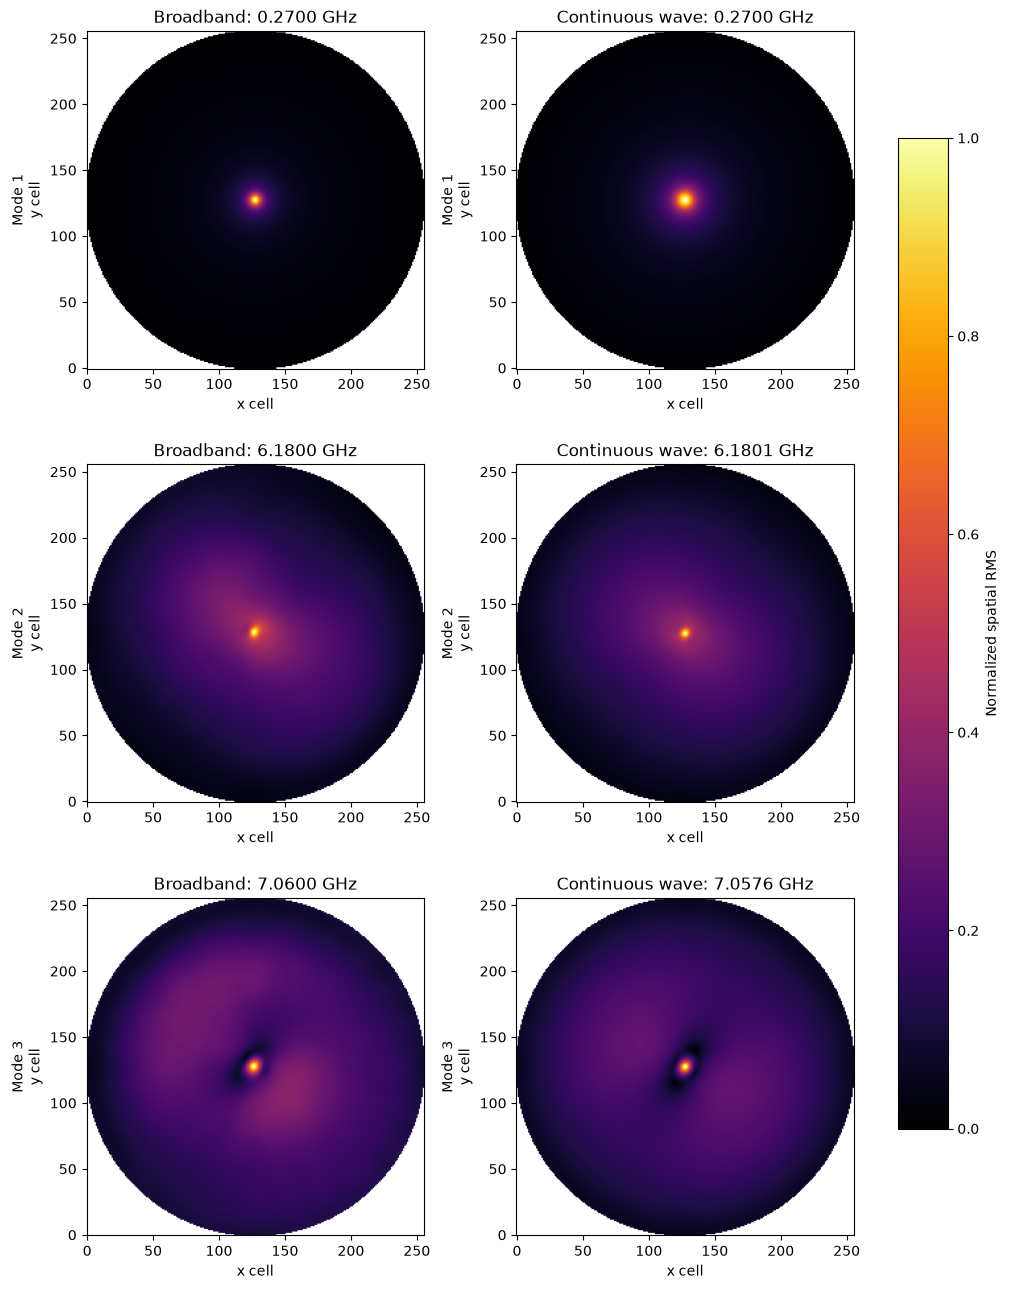

In [36]:
def spatial_rms_map(spectrum_file, segment_index, mask):
    with ovf.reader(spectrum_file) as spectrum:
        values = np.array(spectrum[int(segment_index)].complex_data, copy=True)
    power = np.sum(np.abs(values) ** 2, axis=-1)
    weights = np.asarray(mask)[..., 0]
    weighted_power = np.sum(power * weights, axis=0)
    weight_sum = np.sum(weights, axis=0)
    rms = np.sqrt(
        np.divide(
            weighted_power, weight_sum,
            out=np.zeros_like(weighted_power), where=weight_sum > 0,
        )
    )
    return np.ma.array(rms, mask=weight_sum <= 0)

mode_profiles = []
for run in cw_runs:
    cw_macroparams = ovf.eval_macroparams(run["spectrum_file"], mask=geom_fill)
    broadband_index = np.argmin(np.abs(macroparams.f - run["frequency_hz"]))
    cw_index = np.argmin(np.abs(cw_macroparams.f - run["frequency_hz"]))
    mode_profiles.append(
        {
            **run,
            "broadband_index": broadband_index,
            "cw_index": cw_index,
            "broadband_bin_hz": macroparams.f[broadband_index],
            "cw_bin_hz": cw_macroparams.f[cw_index],
            "broadband_rms": spatial_rms_map(spec_file, broadband_index, geom_fill),
            "cw_rms": spatial_rms_map(run["spectrum_file"], cw_index, geom_fill),
        }
    )

amplitude_cmap = plt.colormaps["inferno"].copy()
amplitude_cmap.set_bad(alpha=0)

fig, axes = plt.subplots(3, 2, figsize=(10, 13), constrained_layout=True)
for row, profile in enumerate(mode_profiles):
    for column, (kind, title) in enumerate(
        (("broadband", "Broadband"), ("cw", "Continuous wave"))
    ):
        rms = profile[f"{kind}_rms"]
        peak = rms.max()
        normalized = rms / peak if peak else rms
        image = axes[row, column].imshow(
            normalized, cmap=amplitude_cmap, origin="lower", vmin=0, vmax=1
        )
        bin_ghz = profile[f"{kind}_bin_hz"] / 1e9
        axes[row, column].set_title(f"{title}: {bin_ghz:.4f} GHz")
        axes[row, column].set_xlabel("x cell")
        axes[row, column].set_ylabel(f"Mode {profile['mode']}\ny cell")

fig.colorbar(image, ax=axes, label="Normalized spatial RMS", shrink=0.8)
plt.show()

## Inspect circular-magnetization phase

Hue shows the phase of the circular components $m_+=m_x+i m_y$ and $m_-=m_x-i m_y$. Cells with zero geometry fill remain transparent. The panel labels report the geometry-weighted power fraction in each orthonormal circular component $(m_x\pm i m_y)/\sqrt{2}$. The $m_+$ and $m_-$ fractions are normalized within the in-plane pair and therefore sum to 100%; $m_z$ is not part of this helicity split. The normalization leaves the displayed phase unchanged.


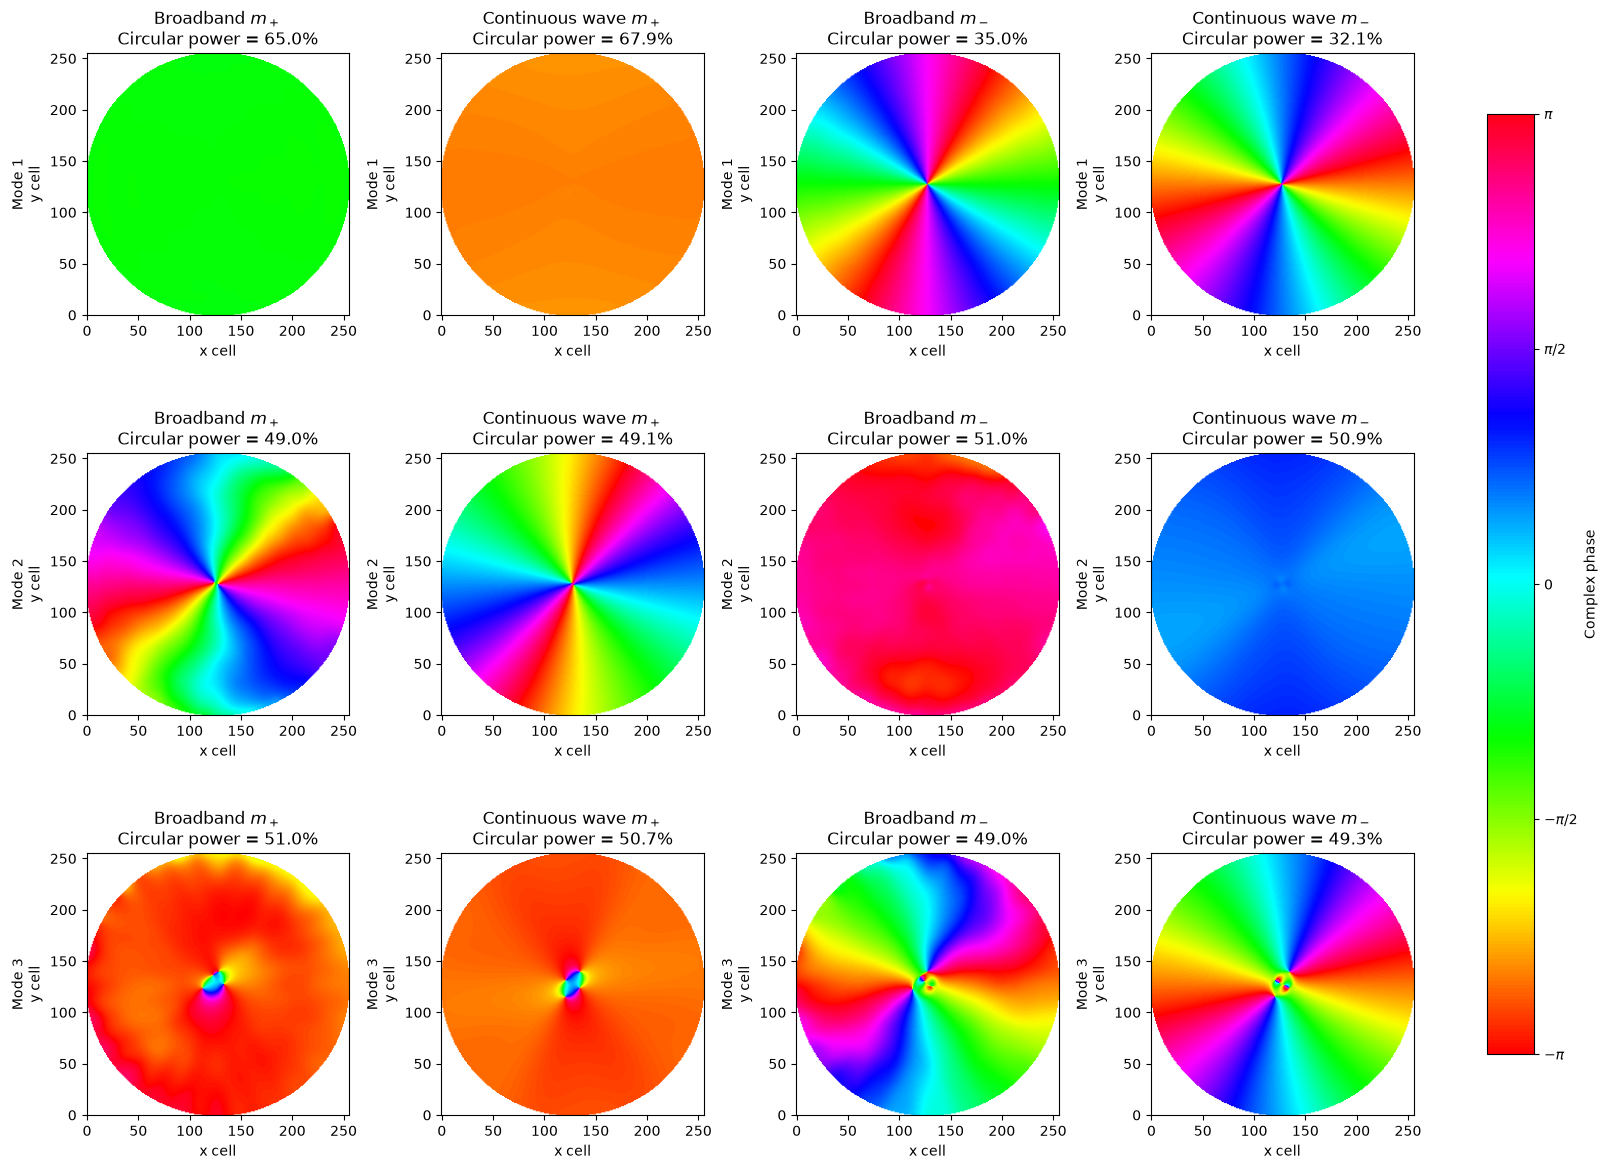

In [38]:
def circular_phase_maps(spectrum_file, segment_index, mask):
    with ovf.reader(spectrum_file) as spectrum:
        values = np.array(spectrum[int(segment_index)].complex_data, copy=True)

    weights = np.asarray(mask)[..., 0]
    weight_sum = np.sum(weights, axis=0)
    total_weight = np.sum(weights)
    if total_weight <= 0:
        raise ValueError("The geometry mask contains no nonzero cells")

    valid = weight_sum > 0
    phases = []
    circular_powers = []
    for circular_component in (
        (values[..., 0] + 1j * values[..., 1]) / np.sqrt(2),
        (values[..., 0] - 1j * values[..., 1]) / np.sqrt(2),
    ):
        weighted = np.sum(circular_component * weights, axis=0)
        averaged = np.divide(
            weighted,
            weight_sum,
            out=np.zeros_like(weighted),
            where=valid,
        )
        phases.append(np.ma.array(np.angle(averaged), mask=~valid))
        circular_powers.append(
            np.sum(np.abs(circular_component) ** 2 * weights) / total_weight
        )

    circular_power = sum(circular_powers)
    power_fractions = [
        power / circular_power if circular_power > 0 else 0.0
        for power in circular_powers
    ]
    return phases, power_fractions

phase_profiles = []
for profile in mode_profiles:
    (broadband_plus, broadband_minus), (
        broadband_plus_fraction, broadband_minus_fraction,
    ) = circular_phase_maps(
        spec_file, profile["broadband_index"], geom_fill
    )
    (cw_plus, cw_minus), (cw_plus_fraction, cw_minus_fraction) = circular_phase_maps(
        profile["spectrum_file"], profile["cw_index"], geom_fill
    )
    phase_profiles.append(
        {
            "broadband_plus": broadband_plus,
            "broadband_plus_fraction": broadband_plus_fraction,
            "broadband_minus": broadband_minus,
            "broadband_minus_fraction": broadband_minus_fraction,
            "cw_plus": cw_plus,
            "cw_plus_fraction": cw_plus_fraction,
            "cw_minus": cw_minus,
            "cw_minus_fraction": cw_minus_fraction,
        }
    )

phase_cmap = plt.colormaps["hsv"].copy()
phase_cmap.set_bad(alpha=0)
columns = (
    ("broadband_plus", "broadband_plus_fraction", r"Broadband $m_+$"),
    ("cw_plus", "cw_plus_fraction", r"Continuous wave $m_+$"),
    ("broadband_minus", "broadband_minus_fraction", r"Broadband $m_-$"),
    ("cw_minus", "cw_minus_fraction", r"Continuous wave $m_-$"),
)

fig, axes = plt.subplots(
    len(mode_profiles), len(columns),
    figsize=(16, 4 * len(mode_profiles)), constrained_layout=True,
)
axes = np.atleast_2d(axes)
for row, (profile, phases) in enumerate(zip(mode_profiles, phase_profiles)):
    for column, (phase_key, fraction_key, title) in enumerate(columns):
        image = axes[row, column].imshow(
            phases[phase_key], cmap=phase_cmap, origin="lower",
            vmin=-np.pi, vmax=np.pi,
        )
        axes[row, column].set_title(
            f"{title}\nCircular power = {phases[fraction_key]:.1%}"
        )
        axes[row, column].set_xlabel("x cell")
        axes[row, column].set_ylabel(f"Mode {profile['mode']}\ny cell")

colorbar = fig.colorbar(
    image, ax=axes, shrink=0.8,
    ticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
)
colorbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
colorbar.set_label("Complex phase")
plt.show()

## Physical context and references

The circular components $m_+=m_x+i m_y$ and $m_-=m_x-i m_y$ separate the two senses of in-plane rotation. This makes the phase maps useful for identifying clockwise and counterclockwise azimuthal vortex modes and their high-frequency doublet.

- S. S. Cherepov *et al.*, [“Core-Core Dynamics in Spin Vortex Pairs,”](https://doi.org/10.1103/PhysRevLett.109.097204) *Physical Review Letters* **109**, 097204 (2012). This work treats the distinct but related collective dynamics produced by strong coupling between two vortex cores.
- B. A. Ivanov and C. E. Zaspel, [“High Frequency Modes in Vortex-State Nanomagnets,”](https://doi.org/10.1103/PhysRevLett.94.027205) *Physical Review Letters* **94**, 027205 (2005). The theory predicts a rich spectrum of high-frequency doublet states.
- C. E. Zaspel, B. A. Ivanov, J. P. Park, and P. A. Crowell, [“Excitations in Vortex-State Permalloy Dots,”](https://doi.org/10.1103/PhysRevB.72.024427) *Physical Review B* **72**, 024427 (2005). This gives a fuller analytical treatment of the higher-frequency azimuthal vortex modes.
- J. P. Park and P. A. Crowell, [“Interactions of Spin Waves with a Magnetic Vortex,”](https://doi.org/10.1103/PhysRevLett.95.167201) *Physical Review Letters* **95**, 167201 (2005). Spatially resolved measurements demonstrate the azimuthal-mode doublet and connect its splitting to coupling with gyrotropic core motion.


## Clean up the temporary workspace

Remove all generated simulation and spectrum files. Skip this cell if you want to inspect or retain them.

In [ ]:
shutil.rmtree(work_dir)
print(f"Removed temporary workspace: {work_dir}")